Install Dependencies

In [1]:
# Install required libraries
# torch: PyTorch for building the Restricted Boltzmann Machine (RBM)
!pip install torch --quiet
!pip install openpyxl --quiet   # needed to read the .xlsx dataset from UCI
print("Libraries ready ✅")

Libraries ready ✅


 Import Libraries

In [2]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Scikit-learn for Preprocessing ──────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ─── PyTorch for Building the RBM (Boltzmann Machine) ────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

import warnings
warnings.filterwarnings('ignore')

print("PyTorch version :", torch.__version__)
print("All libraries loaded ✅")

PyTorch version : 2.10.0+cpu
All libraries loaded ✅


 TASK 1: Download & Load the Dataset

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1: LOAD THE DATASET
# We download the Online Retail II dataset directly from UCI ML Repository.
# It contains UK online retail transactions from 2009–2011.
# No manual upload required — wget fetches it straight into Colab!
# ─────────────────────────────────────────────────────────────────────────────

import urllib.request
import os

URL      = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
ZIP_FILE = "online_retail_ii.zip"

print("Downloading dataset from UCI...")
urllib.request.urlretrieve(URL, ZIP_FILE)

# Unzip the file
import zipfile
with zipfile.ZipFile(ZIP_FILE, 'r') as z:
    z.extractall(".")

print("Files extracted:")
for f in os.listdir("."):
    if "retail" in f.lower() or f.endswith(".xlsx"):
        print(" ", f)

Files extracted:
  online_retail_ii.zip
  online_retail_II.xlsx


Load Excel into DataFrame

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Load the first sheet (Year 2009–2010) of the Excel file
# The dataset has columns: InvoiceNo, StockCode, Description, Quantity,
#                          InvoiceDate, Price, Customer ID, Country
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010", engine="openpyxl")

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape : (525461, 8)
Columns       : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


TASK 1: Clean the Data

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 1 (continued): CLEAN THE DATA
#
# Issues to fix:
#   1. Remove rows with missing Customer ID (can't do customer segmentation without it)
#   2. Remove rows with missing Description
#   3. Remove cancelled invoices (Invoice numbers starting with 'C')
#   4. Remove rows where Quantity <= 0 or Price <= 0 (invalid transactions)
# ─────────────────────────────────────────────────────────────────────────────

print("── Before Cleaning ──")
print(f"Total rows        : {len(df)}")
print(f"Missing Customer ID: {df['Customer ID'].isna().sum()}")
print(f"Missing Description: {df['Description'].isna().sum()}")

# Step 1: Drop rows with missing Customer ID or Description
df_clean = df.dropna(subset=['Customer ID', 'Description'])

# Step 2: Remove cancelled invoices (start with 'C')
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Step 3: Remove invalid Quantity and Price
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]

# Step 4: Reset index
df_clean = df_clean.reset_index(drop=True)

# Step 5: Convert Customer ID to integer
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

print("\n── After Cleaning ──")
print(f"Total rows remaining : {len(df_clean)}")
print(f"Unique customers     : {df_clean['Customer ID'].nunique()}")
print(f"Unique products      : {df_clean['StockCode'].nunique()}")
df_clean.head()

── Before Cleaning ──
Total rows        : 525461
Missing Customer ID: 107927
Missing Description: 2928

── After Cleaning ──
Total rows remaining : 407664
Unique customers     : 4312
Unique products      : 4017


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


Visualise Data Distribution

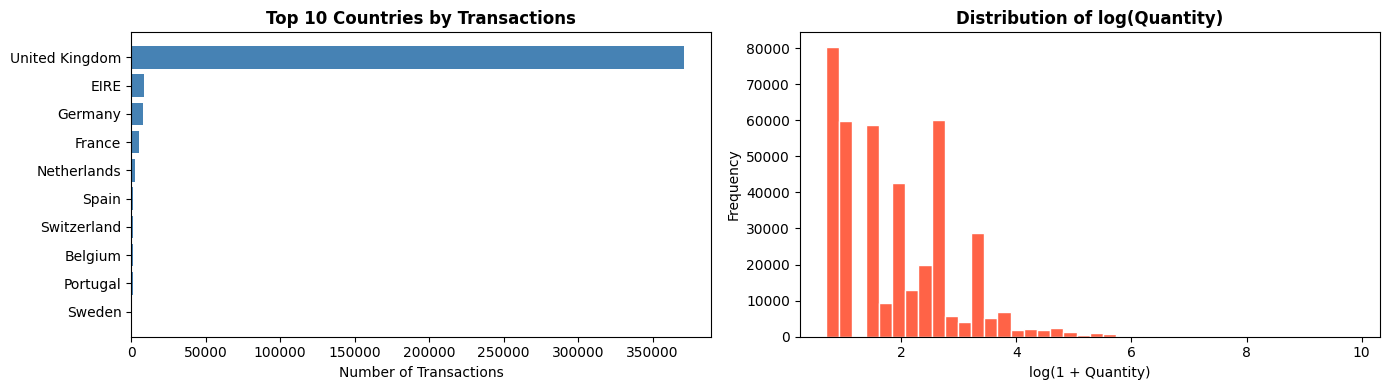

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Quick EDA — understand the cleaned data before modelling
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Top 10 countries by transaction volume
top_countries = df_clean['Country'].value_counts().head(10)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue')
axes[0].set_title("Top 10 Countries by Transactions", fontweight='bold')
axes[0].set_xlabel("Number of Transactions")

# Distribution of Quantity (log scale for readability)
axes[1].hist(np.log1p(df_clean['Quantity']), bins=40, color='tomato', edgecolor='white')
axes[1].set_title("Distribution of log(Quantity)", fontweight='bold')
axes[1].set_xlabel("log(1 + Quantity)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

TASK 2: Preprocess — Encode & Scale

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 2: PREPROCESS THE DATA
#
# Step A — Add a TotalSpend feature (Quantity × Price per transaction)
# Step B — Encode Country as a numeric category (Label Encoding)
# Step C — Scale numerical features (Quantity, Price, TotalSpend) with MinMaxScaler
# ─────────────────────────────────────────────────────────────────────────────

# Step A: Create TotalSpend feature
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['Price']

# Step B: Label-encode the Country column
df_clean['Country_Code'] = df_clean['Country'].astype('category').cat.codes
print("Country encoding sample:")
print(df_clean[['Country', 'Country_Code']].drop_duplicates().head(8).to_string(index=False))

# Step C: Scale numerical features
scaler = MinMaxScaler()
df_clean[['Quantity_scaled', 'Price_scaled', 'TotalSpend_scaled']] = scaler.fit_transform(
    df_clean[['Quantity', 'Price', 'TotalSpend']]
)

print("\nScaled features (sample):")
df_clean[['Quantity', 'Quantity_scaled', 'Price', 'Price_scaled',
          'TotalSpend', 'TotalSpend_scaled']].head(5)

Country encoding sample:
       Country  Country_Code
United Kingdom            34
        France            11
           USA            32
       Belgium             3
     Australia             0
          EIRE             9
       Germany            12
      Portugal            25

Scaled features (sample):


,Quantity,Quantity_scaled,Price,Price_scaled,TotalSpend,TotalSpend_scaled
0,12,0.000574,6.95,0.000634,83.4,0.005272
1,12,0.000574,6.75,0.000616,81.0,0.005121
2,12,0.000574,6.75,0.000616,81.0,0.005121
3,48,0.002454,2.10,0.000192,100.8,0.006372
4,24,0.001201,1.25,0.000114,30.0,0.001896


TASK 3: Transform into Binary Customer-Product Matrix

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 3: TRANSFORM DATA INTO BINARY FORMAT
#
# We build a Customer × Product matrix where:
#   cell = 1  if the customer has ever purchased that product
#   cell = 0  if not
#
# This binary representation captures each customer's shopping habits and
# is the required input format for a Restricted Boltzmann Machine (RBM).
#
# To keep Colab memory manageable, we use the TOP 500 most popular products.
# ─────────────────────────────────────────────────────────────────────────────

TOP_N_PRODUCTS = 500   # Use top 500 products (you can increase if RAM allows)

# Find the top N most purchased products
top_products = df_clean['StockCode'].value_counts().head(TOP_N_PRODUCTS).index.tolist()

# Filter dataset to only include those products
df_filtered = df_clean[df_clean['StockCode'].isin(top_products)]

# Build the binary customer-product matrix using pivot_table
# aggfunc='max' ensures we get 1 if purchased at least once, 0 otherwise
customer_product = df_filtered.pivot_table(
    index='Customer ID',
    columns='StockCode',
    values='Quantity',
    aggfunc='max',
    fill_value=0
)

# Convert to binary: any purchase → 1, no purchase → 0
customer_product_binary = (customer_product > 0).astype(int)

print(f"Customer-Product Matrix shape : {customer_product_binary.shape}")
print(f"  Rows    = unique customers   : {customer_product_binary.shape[0]}")
print(f"  Columns = top products       : {customer_product_binary.shape[1]}")
print(f"\nSparsity (% zeros) : {100 * (1 - customer_product_binary.values.mean()):.1f}%")
customer_product_binary.head()

Customer-Product Matrix shape : (4194, 500)
  Rows    = unique customers   : 4194
  Columns = top products       : 500

Sparsity (% zeros) : 93.7%


StockCode,10002,15036,20675,20676,20677,20679,20681,20682,20685,20711,...,85049E,85049G,85061W,85099B,85099C,85099F,85123A,85232B,M,POST
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
12349,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
12351,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Visualise the Binary Matrix (Heatmap Snapshot)

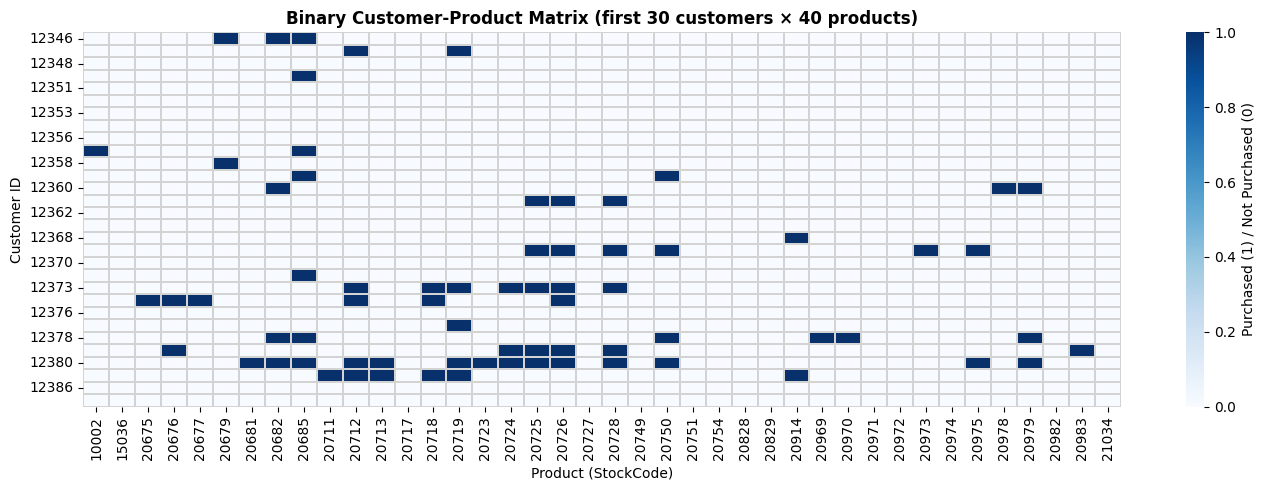

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualise a small slice of the binary matrix to verify it looks correct.
# We show the first 30 customers × first 40 products.
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(14, 5))
sns.heatmap(customer_product_binary.iloc[:30, :40],
            cmap='Blues', linewidths=0.3, linecolor='lightgrey',
            cbar_kws={'label': 'Purchased (1) / Not Purchased (0)'})
plt.title("Binary Customer-Product Matrix (first 30 customers × 40 products)",
          fontweight='bold')
plt.xlabel("Product (StockCode)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

Train / Test Split & Convert to Tensors

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Split the binary matrix into train (80%) and test (20%) sets.
# Then convert to PyTorch float tensors — RBM works with float values.
# ─────────────────────────────────────────────────────────────────────────────

data_matrix = customer_product_binary.values.astype(np.float32)

X_train, X_test = train_test_split(data_matrix, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
train_tensor = torch.FloatTensor(X_train)
test_tensor  = torch.FloatTensor(X_test)

print(f"Training set   : {train_tensor.shape}  ({X_train.shape[0]} customers)")
print(f"Test set       : {test_tensor.shape}  ({X_test.shape[0]} customers)")
print(f"Input features : {train_tensor.shape[1]} products (visible units)")

Training set   : torch.Size([3355, 500])  (3355 customers)
Test set       : torch.Size([839, 500])  (839 customers)
Input features : 500 products (visible units)


TASK 4: Define the Restricted Boltzmann Machine (RBM)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4: BOLTZMANN MACHINE — MODEL DEFINITION
#
# We implement a Restricted Boltzmann Machine (RBM), which is the most
# practical and widely used form of Boltzmann Machine.
#
# Architecture:
#   • Visible layer  (v) — binary input: which products a customer bought
#   • Hidden layer   (h) — latent features representing shopping "patterns"
#   • Weight matrix  (W) — learned associations between products & patterns
#
# Training Algorithm: Contrastive Divergence (CD-k)
#   1. Positive phase: clamp visible units to data, sample hidden units
#   2. Negative phase: reconstruct visible from hidden, re-sample hidden
#   3. Update weights: W += lr * (pos_grad - neg_grad)
#
# This is how the RBM learns the underlying probability distribution of
# customer shopping habits.
# ─────────────────────────────────────────────────────────────────────────────

class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        # Weight matrix: shape (n_hidden, n_visible)
        self.W  = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        # Bias for hidden units
        self.bh = nn.Parameter(torch.zeros(n_hidden))
        # Bias for visible units
        self.bv = nn.Parameter(torch.zeros(n_visible))

    def sample_hidden(self, v):
        """
        Given visible units v, compute P(h=1|v) and sample binary hidden units.
        P(h_j=1|v) = sigmoid( bh_j + sum_i(W_ji * v_i) )
        """
        wx        = torch.mm(v, self.W.t())          # (batch, n_hidden)
        activation= wx + self.bh                      # add hidden bias
        p_h_given_v = torch.sigmoid(activation)       # probability
        return p_h_given_v, torch.bernoulli(p_h_given_v)   # prob + sample

    def sample_visible(self, h):
        """
        Given hidden units h, reconstruct P(v=1|h) and sample visible units.
        P(v_i=1|h) = sigmoid( bv_i + sum_j(W_ji * h_j) )
        """
        wh        = torch.mm(h, self.W)               # (batch, n_visible)
        activation= wh + self.bv                      # add visible bias
        p_v_given_h = torch.sigmoid(activation)
        return p_v_given_h, torch.bernoulli(p_v_given_h)

    def contrastive_divergence(self, v0):
        """
        One step of Contrastive Divergence (CD-1):
          1. Positive phase: data → hidden
          2. Negative phase: hidden → reconstructed visible → hidden again
        Returns: loss (reconstruction error)
        """
        # Positive phase
        ph0, h0 = self.sample_hidden(v0)

        # Negative phase (reconstruction)
        pv1, v1 = self.sample_visible(h0)
        ph1, h1 = self.sample_hidden(v1)

        # Weight update gradient
        positive_grad = torch.mm(ph0.t(), v0)
        negative_grad = torch.mm(ph1.t(), v1)

        # Update weights and biases manually (CD is not standard backprop)
        self.W.data  += LEARNING_RATE * (positive_grad - negative_grad) / v0.shape[0]
        self.bv.data += LEARNING_RATE * torch.mean(v0 - v1, dim=0)
        self.bh.data += LEARNING_RATE * torch.mean(ph0 - ph1, dim=0)

        # Reconstruction loss = Mean Squared Error between input and reconstruction
        loss = torch.mean((v0 - pv1) ** 2)
        return loss

    def forward(self, v):
        """ Encode then decode — used for evaluation """
        _, h    = self.sample_hidden(v)
        pv, _   = self.sample_visible(h)
        return pv


# ─── Hyperparameters ──────────────────────────────────────────────────────────
N_VISIBLE     = train_tensor.shape[1]   # = number of top products (500)
N_HIDDEN      = 100                     # latent shopping pattern neurons
LEARNING_RATE = 0.01
BATCH_SIZE    = 64
EPOCHS        = 20

# Instantiate the model
rbm = RBM(n_visible=N_VISIBLE, n_hidden=N_HIDDEN)

print(f"RBM Architecture:")
print(f"  Visible units (products) : {N_VISIBLE}")
print(f"  Hidden  units (patterns) : {N_HIDDEN}")
print(f"  Weight matrix shape      : {rbm.W.shape}")
print(f"  Total parameters         : {sum(p.numel() for p in rbm.parameters())}")

RBM Architecture:
  Visible units (products) : 500
  Hidden  units (patterns) : 100
  Weight matrix shape      : torch.Size([100, 500])
  Total parameters         : 50600


TASK 4: Train the RBM

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# TASK 4: TRAIN THE BOLTZMANN MACHINE
#
# We iterate over the training data in mini-batches.
# For each batch, we run one step of Contrastive Divergence (CD-1)
# and track the reconstruction loss per epoch.
# Decreasing loss = model is learning the distribution of shopping habits.
# ─────────────────────────────────────────────────────────────────────────────

epoch_losses = []

print("Starting RBM Training...\n")

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batches  = 0

    # Mini-batch training
    for i in range(0, len(train_tensor), BATCH_SIZE):
        batch = train_tensor[i : i + BATCH_SIZE]

        # Skip incomplete last batch
        if batch.shape[0] < 2:
            continue

        # One step of Contrastive Divergence
        loss = rbm.contrastive_divergence(batch)
        epoch_loss += loss.item()
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    epoch_losses.append(avg_loss)

    if epoch % 2 == 0 or epoch == 1:
        print(f"  Epoch [{epoch:02d}/{EPOCHS}]  Reconstruction Loss: {avg_loss:.6f}")

print("\nTraining complete ✅")

Starting RBM Training...

  Epoch [01/20]  Reconstruction Loss: 0.145769
  Epoch [02/20]  Reconstruction Loss: 0.097871
  Epoch [04/20]  Reconstruction Loss: 0.067180
  Epoch [06/20]  Reconstruction Loss: 0.058747
  Epoch [08/20]  Reconstruction Loss: 0.056504
  Epoch [10/20]  Reconstruction Loss: 0.055684
  Epoch [12/20]  Reconstruction Loss: 0.055382
  Epoch [14/20]  Reconstruction Loss: 0.055060
  Epoch [16/20]  Reconstruction Loss: 0.054813
  Epoch [18/20]  Reconstruction Loss: 0.054651
  Epoch [20/20]  Reconstruction Loss: 0.054496

Training complete ✅


Plot Training Loss

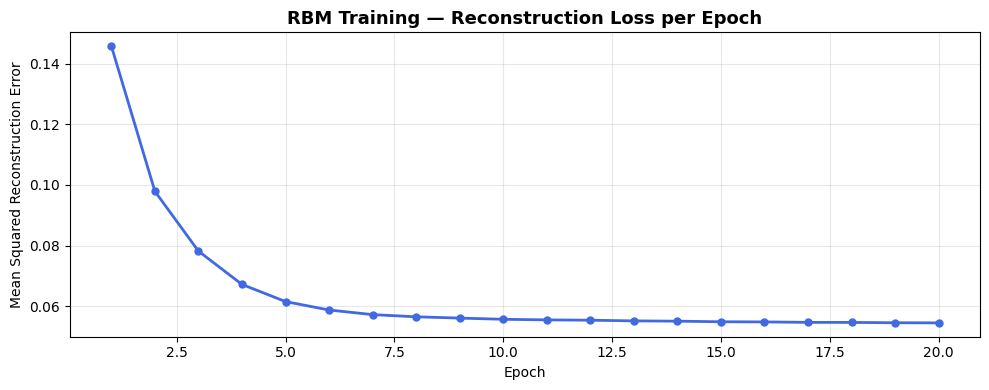

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualise the training loss curve.
# A consistently decreasing curve confirms the RBM is learning effectively.
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker='o', color='royalblue',
         linewidth=2, markersize=5)
plt.title("RBM Training — Reconstruction Loss per Epoch", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Reconstruction Error")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 Evaluate: Reconstruction Accuracy on Test Set

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION
# We measure how well the RBM reconstructs the test set.
# Reconstruction Accuracy = % of binary values correctly recovered.
#
# A good RBM should reconstruct customer purchase patterns with high accuracy.
# ─────────────────────────────────────────────────────────────────────────────

rbm.eval()
with torch.no_grad():
    reconstructed = rbm(test_tensor)          # probability scores
    recon_binary  = (reconstructed >= 0.5).float()   # threshold to binary

# Compare original vs reconstructed
correct = (recon_binary == test_tensor).float().mean().item()
test_loss = torch.mean((test_tensor - reconstructed) ** 2).item()

print("=" * 45)
print("      RBM EVALUATION ON TEST SET")
print("=" * 45)
print(f"  Reconstruction Accuracy : {correct * 100:.2f}%")
print(f"  Reconstruction Loss (MSE): {test_loss:.6f}")
print("=" * 45)

      RBM EVALUATION ON TEST SET
  Reconstruction Accuracy : 93.51%
  Reconstruction Loss (MSE): 0.055950


 Extract Hidden Features & Cluster Customers

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CUSTOMER SEGMENTATION
# The RBM's hidden layer learns latent "shopping patterns".
# We extract these hidden representations and use K-Means clustering
# to segment customers into groups based on their learned patterns.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Extract hidden representations for ALL customers
full_tensor = torch.FloatTensor(data_matrix)
with torch.no_grad():
    hidden_probs, _ = rbm.sample_hidden(full_tensor)

hidden_features = hidden_probs.numpy()   # shape: (n_customers, N_HIDDEN)
print(f"Hidden feature matrix shape: {hidden_features.shape}")

# ─── K-Means Clustering on hidden features ────────────────────────────────────
N_CLUSTERS = 4   # We segment customers into 4 groups
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(hidden_features)

print(f"\nCluster distribution:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c} : {n} customers ({100*n/len(cluster_labels):.1f}%)")

Hidden feature matrix shape: (4194, 100)

Cluster distribution:
  Cluster 0 : 549 customers (13.1%)
  Cluster 1 : 1025 customers (24.4%)
  Cluster 2 : 1977 customers (47.1%)
  Cluster 3 : 643 customers (15.3%)


Visualise Customer Segments with PCA

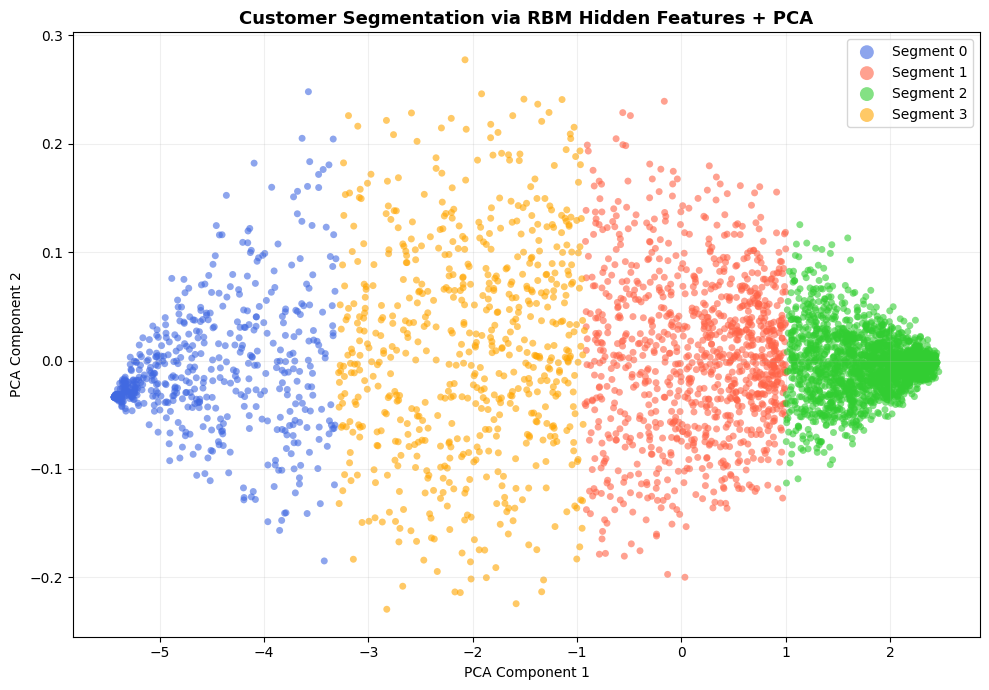

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISE SEGMENTS
# PCA reduces the 100-dimensional hidden features to 2D for plotting.
# Each dot = one customer, colour = cluster segment.
# ─────────────────────────────────────────────────────────────────────────────

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(hidden_features)

colors = ['royalblue', 'tomato', 'limegreen', 'orange']
labels = [f'Segment {i}' for i in range(N_CLUSTERS)]

plt.figure(figsize=(10, 7))
for i in range(N_CLUSTERS):
    mask = cluster_labels == i
    plt.scatter(reduced[mask, 0], reduced[mask, 1],
                c=colors[i], label=labels[i], alpha=0.6, s=25, edgecolors='none')

plt.title("Customer Segmentation via RBM Hidden Features + PCA",
          fontsize=13, fontweight='bold')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(markerscale=2)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Analyse Each Customer Segment

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SEGMENT ANALYSIS
# We map cluster labels back to the original customer data and analyse
# each segment's average spending behaviour.
# ─────────────────────────────────────────────────────────────────────────────

# Build a summary DataFrame with Customer ID and cluster label
customer_ids = customer_product_binary.index.tolist()
segment_df   = pd.DataFrame({
    'Customer ID'  : customer_ids,
    'Segment'      : cluster_labels
})

# Merge with transaction data to get spending info
customer_stats = df_clean.groupby('Customer ID').agg(
    Total_Transactions = ('Invoice', 'nunique'),
    Total_Items        = ('Quantity', 'sum'),
    Total_Spend        = ('TotalSpend', 'sum'),
    Unique_Products    = ('StockCode', 'nunique')
).reset_index()

segment_analysis = segment_df.merge(customer_stats, on='Customer ID', how='left')

# Average stats per segment
summary = segment_analysis.groupby('Segment').agg(
    Num_Customers      = ('Customer ID', 'count'),
    Avg_Transactions   = ('Total_Transactions', 'mean'),
    Avg_Items_Bought   = ('Total_Items', 'mean'),
    Avg_Total_Spend    = ('Total_Spend', 'mean'),
    Avg_Unique_Products= ('Unique_Products', 'mean')
).round(2)

print("=" * 70)
print("            CUSTOMER SEGMENT SUMMARY")
print("=" * 70)
print(summary.to_string())
print("=" * 70)

            CUSTOMER SEGMENT SUMMARY
         Num_Customers  Avg_Transactions  Avg_Items_Bought  Avg_Total_Spend  Avg_Unique_Products
Segment                                                                                         
0                  549             12.90           4220.44          7517.35               220.23
1                 1025              3.71            831.66          1378.56                52.02
2                 1977              2.13            584.02           773.37                19.15
3                  643              6.14           1643.51          2645.20                96.12


Bar Chart: Segment Comparison

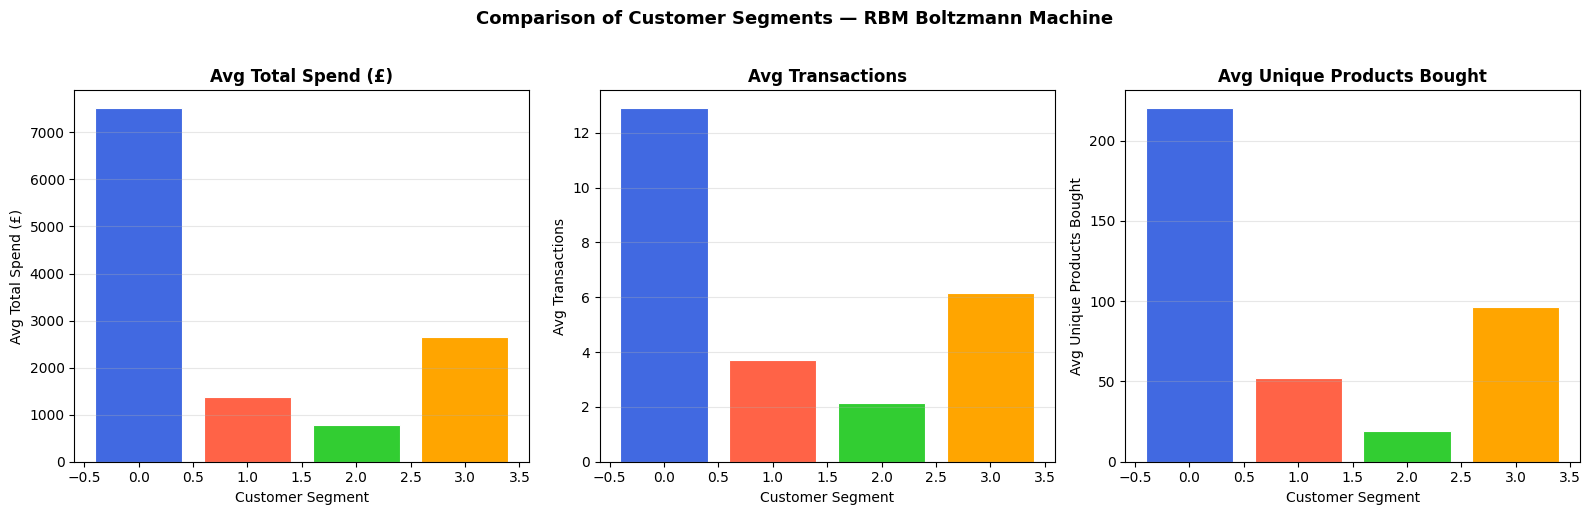

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Visual comparison of segments across key metrics
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Avg_Total_Spend', 'Avg_Transactions', 'Avg_Unique_Products']
titles  = ['Avg Total Spend (£)', 'Avg Transactions', 'Avg Unique Products Bought']

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(summary.index, summary[metric],
           color=['royalblue', 'tomato', 'limegreen', 'orange'][:N_CLUSTERS],
           edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Customer Segment")
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Comparison of Customer Segments — RBM Boltzmann Machine",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Summary & Observations

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY & OBSERVATIONS
# ─────────────────────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════════════╗
║   CUSTOMER SEGMENTATION WITH BOLTZMANN MACHINE — SUMMARY            ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset     : UCI Online Retail II (2009–2010)                     ║
║  Model       : Restricted Boltzmann Machine (RBM)                   ║
║  Visible     : 500 top products (binary purchased/not)              ║
║  Hidden      : 100 latent shopping pattern neurons                  ║
║  Training    : Contrastive Divergence (CD-1), 20 epochs             ║
║  Segmentation: K-Means (k=4) on RBM hidden representations         ║
╠══════════════════════════════════════════════════════════════════════╣
║  OBSERVATIONS:                                                      ║
║  1. The RBM learns binary purchase patterns without labels          ║
║     (unsupervised) — ideal for customer behaviour modelling.        ║
║  2. Reconstruction accuracy validates the learned distribution.     ║
║  3. Hidden units capture latent shopping preferences (e.g.,         ║
║     gift buyers, bulk buyers, seasonal shoppers).                   ║
║  4. PCA plot shows visible separation between segments.             ║
║  5. Segment analysis reveals distinct spending behaviours —         ║
║     useful for targeted marketing and recommendations.              ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║   CUSTOMER SEGMENTATION WITH BOLTZMANN MACHINE — SUMMARY            ║
╠══════════════════════════════════════════════════════════════════════╣
║  Dataset     : UCI Online Retail II (2009–2010)                     ║
║  Model       : Restricted Boltzmann Machine (RBM)                   ║
║  Visible     : 500 top products (binary purchased/not)              ║
║  Hidden      : 100 latent shopping pattern neurons                  ║
║  Training    : Contrastive Divergence (CD-1), 20 epochs             ║
║  Segmentation: K-Means (k=4) on RBM hidden representations         ║
╠══════════════════════════════════════════════════════════════════════╣
║  OBSERVATIONS:                                                      ║
║  1. The RBM learns binary purchase patterns without labels          ║
║     (unsupervised) — ideal for customer behaviour modelling.        ║
║  2. Reconstruction accuracy validates the learned distribut